In [1]:
import sys
sys.path.insert(1, '../src/')
from RipUOT import RipUOT
import evals 
import torch
import numpy as np

/opt/anaconda3/envs/CRUOT_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = 1
np.random.seed(1) 
torch.manual_seed(1)
torch.use_deterministic_algorithms(True)

In [3]:
x_s_np = np.load("../datasets/SNAREseq/SNAREseq_atac_feat.npy")
x_s_np = np.float64(x_s_np)
type_atac = np.loadtxt("../datasets/SNAREseq/SNAREseq_atac_types.txt")
type_atac = type_atac.astype(np.int64)

# --- Subsample the source data -----------
# Specify the proportions for each class
props_s = {
    1: 0.50,  
    2: 0.75, 
    3: 0.50,  
    4: 0.75   
}

subsets_s = []
labels_s = []

for cls, prop in props_s.items():
    # Get all indices for this class
    cls_indices = np.where(type_atac == cls)[0]
    n_samples = int(len(cls_indices) * prop)  # number to sample
    chosen = np.random.choice(cls_indices, n_samples, replace=False)
    subsets_s.append(x_s_np[chosen])
    labels_s.append(type_atac[chosen])

# Concatenate into a new dataset
x_s_sub = np.vstack(subsets_s)
labels_s_sub = np.hstack(labels_s)

# -------------------------------
row_norms_atac = np.linalg.norm(x_s_sub,  axis=1, keepdims=True)
row_norms_atac[row_norms_atac == 0] = 1
x_s_sub = x_s_sub / row_norms_atac
x_s_sub = x_s_sub - x_s_sub.mean(axis=0)
# -------------------------------
x_s = torch.tensor(x_s_sub, dtype=torch.float64)
type_atac = labels_s_sub.astype(np.int64)

In [4]:
x_t_np = np.load("../datasets/SNAREseq/SNAREseq_rna_feat.npy")
x_t_np = np.float64(x_t_np)
type_rna = np.loadtxt("../datasets/SNAREseq/SNAREseq_rna_types.txt") 
type_rna = type_rna.astype(np.int64)

props_t = {
    1: 0.75, 
    2: 0.50,  
    3: 0.75,  
    4: 0.50    
}

subsets_t = []
labels_t = []

for cls, prop in props_t.items():
    # Get all indices for this class
    cls_indices = np.where(type_rna == cls)[0]
    n_samples = int(len(cls_indices) * prop)  # number to sample
    chosen = np.random.choice(cls_indices, n_samples, replace=False)
    subsets_t.append(x_t_np[chosen])
    labels_t.append(type_rna[chosen])

x_t_sub = np.vstack(subsets_t)
labels_t_sub = np.hstack(labels_t)

# -------------------------------
row_norms_rna = np.linalg.norm(x_t_sub,  axis=1, keepdims=True)
row_norms_rna[row_norms_rna == 0] = 1
x_t_sub = x_t_sub / row_norms_rna
x_t_sub = x_t_sub - x_t_sub.mean(axis=0)
# -------------------------------
x_t = torch.tensor(x_t_sub, dtype=torch.float64)
type_rna = labels_t_sub.astype(np.int64)

In [5]:
device = torch.device("cpu")

x_s = x_s.to(device)
x_t = x_t.to(device)

In [6]:
ripuot = RipUOT(x_s, x_t, lambd=0.07, lambd_2=None, eps=5e-3, log=False)
ripuot.fit(k_cost=1.0, max_iter=100, tol=1e-6, max_iter_sinkhorn=10000, tol_sinkhorn=1e-6, device=device, verbose=True, log=False)
X_s, X_t = ripuot.align(eps_1=5e-3, max_iter_sinkhorn=10000, tol_sinkhorn=1e-6)

1
Sinkhorn stopped at iteration 57 with error 9.247955625527049e-07
Mean f: -0.00708752885248296 Mean g: -0.007333255676459989
error M: tensor(1.2537, dtype=torch.float64)
error P: tensor(0.0031, dtype=torch.float64)
2
Sinkhorn stopped at iteration 76 with error 8.720725561128795e-07
Mean f: -0.07616417743565788 Mean g: -0.0954177611704887
error M: tensor(0.4270, dtype=torch.float64)
error P: tensor(0.0244, dtype=torch.float64)
3
Sinkhorn stopped at iteration 64 with error 8.987552573835877e-07
Mean f: -0.09112408259848392 Mean g: -0.10845687674330087
error M: tensor(0.2470, dtype=torch.float64)
error P: tensor(0.0160, dtype=torch.float64)
4
Sinkhorn stopped at iteration 64 with error 9.24085512277184e-07
Mean f: -0.10316891998891237 Mean g: -0.11112029249896391
error M: tensor(0.2416, dtype=torch.float64)
error P: tensor(0.0152, dtype=torch.float64)
5
Sinkhorn stopped at iteration 63 with error 9.768538556942374e-07
Mean f: -0.10862897750515169 Mean g: -0.11051155760512993
error M: te

In [7]:
lta = evals.compute_lta(X_s.numpy(), X_t.numpy(), type_atac, type_rna, n=5)
print("LTA:", lta)

LTA: 0.7605633802816901


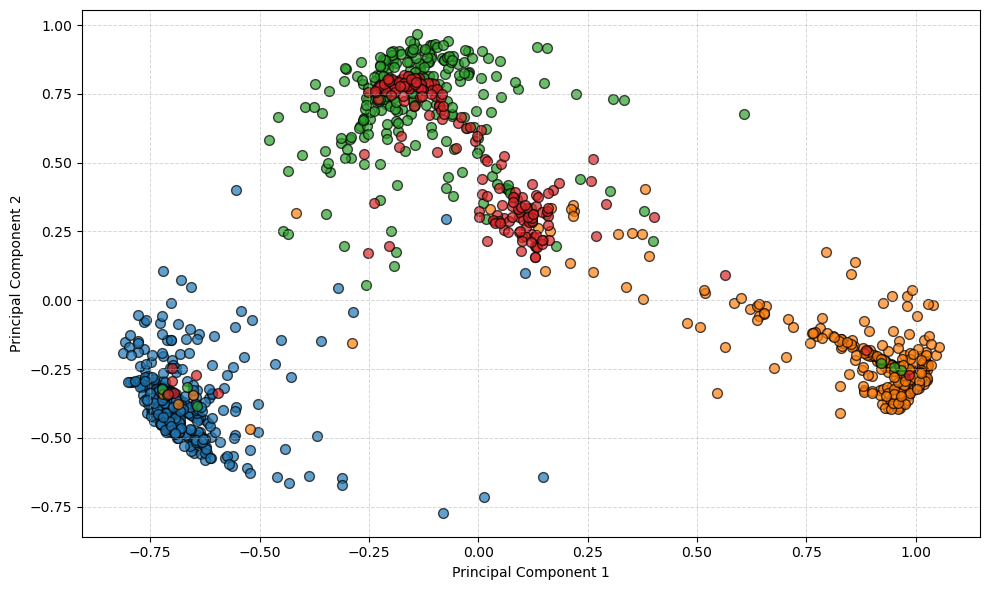

In [8]:
evals.plot_projection(
    source_proj=X_s.numpy(),    # your projected source domain (n_samples, d)
    source_labels=type_atac,    # true source labels (1D array)
    target_data=X_t.numpy(),    # your original target domain (n_samples, d)
    target_labels=type_rna,   # true target labels (1D array)
    method='pca',               # or 'umap'
    save_pdf=True
)